# Insurance Cost Prediction

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../insurance.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.shape

(1338, 7)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(1)

### Data Understanding Observations

1. The dataset contains 1338 rows and 7 columns.
2. The dataset consists of both numerical and categorical features.
3. Numerical features include age, bmi, children, and charges.
4. Categorical features include sex, smoker, and region.
5. The target variable is charges.
6. No missing values were found in the dataset.
7. One duplicate record was identified.

In [8]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [9]:
df.shape

(1337, 7)

In [11]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# EDA

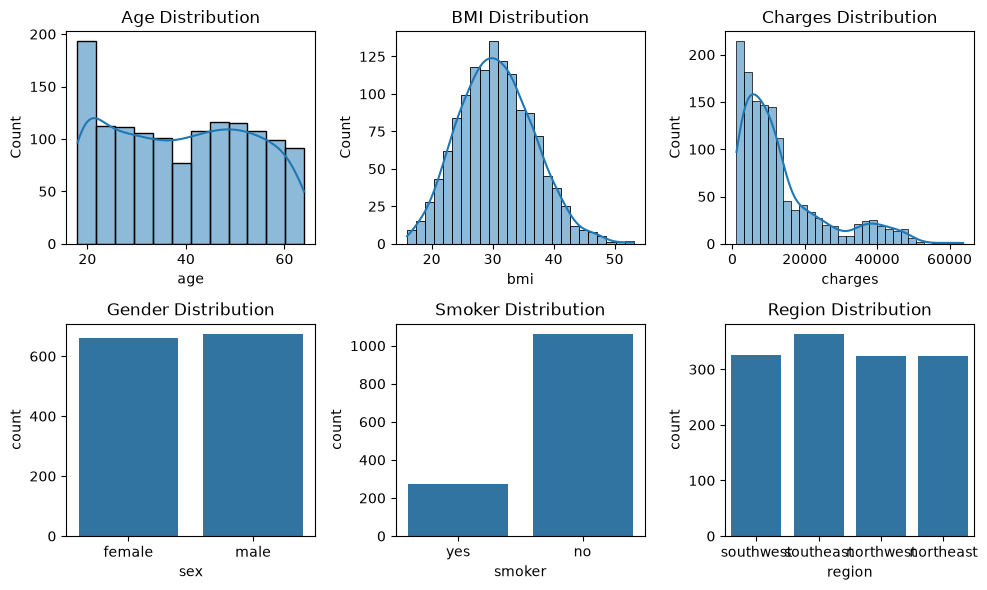

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(10,6))

# Age
sns.histplot(df['age'], kde=True, ax=axes[0,0])
axes[0,0].set_title('Age Distribution')

# BMI
sns.histplot(df['bmi'], kde=True, ax=axes[0,1])
axes[0,1].set_title('BMI Distribution')

# Charges
sns.histplot(df['charges'], kde=True, ax=axes[0,2])
axes[0,2].set_title('Charges Distribution')

# Gender
sns.countplot(x='sex', data=df, ax=axes[1,0])
axes[1,0].set_title('Gender Distribution')

# Smoker
sns.countplot(x='smoker', data=df, ax=axes[1,1])
axes[1,1].set_title('Smoker Distribution')

# Region
sns.countplot(x='region', data=df, ax=axes[1,2])
axes[1,2].set_title('Region Distribution')

plt.tight_layout()
plt.show()

### Univariate Analysis Observations

1. Age is fairly evenly distributed across different age groups, with a slightly higher concentration of younger individuals around 18–20 years.

2. BMI follows an approximately normal distribution centered around 30, indicating that most beneficiaries have BMI values between 25 and 35.

3. Insurance charges are highly right-skewed, meaning most customers incur lower medical expenses while a small number of customers have very high insurance costs.

4. Male and female beneficiaries are almost equally represented in the dataset, indicating a balanced gender distribution.

5. Non-smokers significantly outnumber smokers in the dataset.

6. The distribution across regions is relatively balanced, with the southeast region having a slightly higher number of beneficiaries.

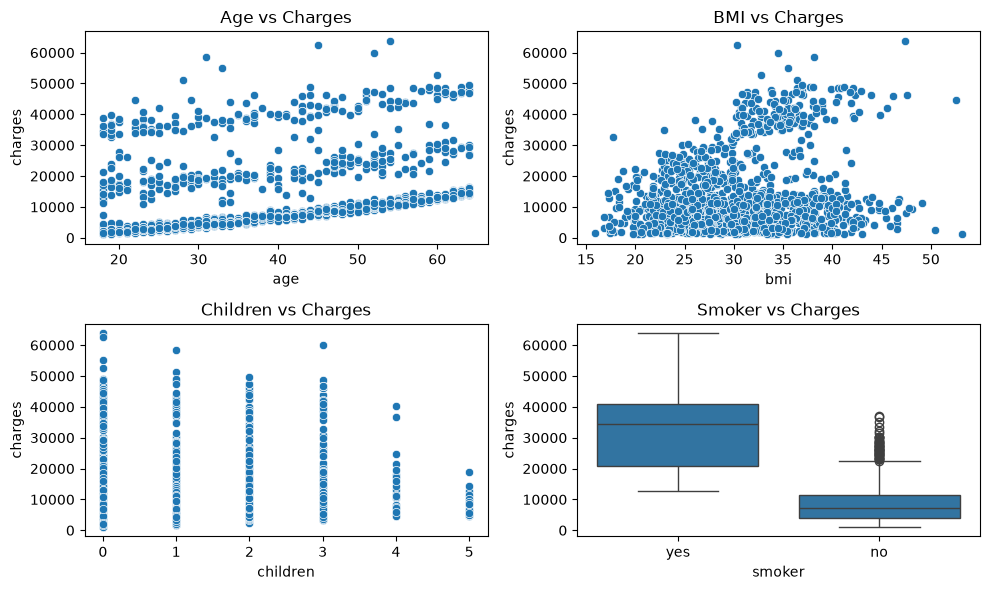

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(10,6))

# Age vs Charges
sns.scatterplot(
    data=df,
    x='age',
    y='charges',
    ax=axes[0,0]
)
axes[0,0].set_title('Age vs Charges')

# BMI vs Charges
sns.scatterplot(
    data=df,
    x='bmi',
    y='charges',
    ax=axes[0,1]
)
axes[0,1].set_title('BMI vs Charges')

# Children vs Charges
sns.scatterplot(
    data=df,
    x='children',
    y='charges',
    ax=axes[1,0]
)
axes[1,0].set_title('Children vs Charges')

# Smoker vs Charges
sns.boxplot(
    data=df,
    x='smoker',
    y='charges',
    ax=axes[1,1]
)
axes[1,1].set_title('Smoker vs Charges')

plt.tight_layout()
plt.show()

### Relationship Analysis Observations

1. Insurance charges generally increase with age.
2. Higher BMI is associated with higher insurance charges.
3. Number of children has a limited impact on insurance charges.
4. Smokers have significantly higher insurance charges than non-smokers.
5. Smoking appears to be one of the strongest factors affecting insurance cost.

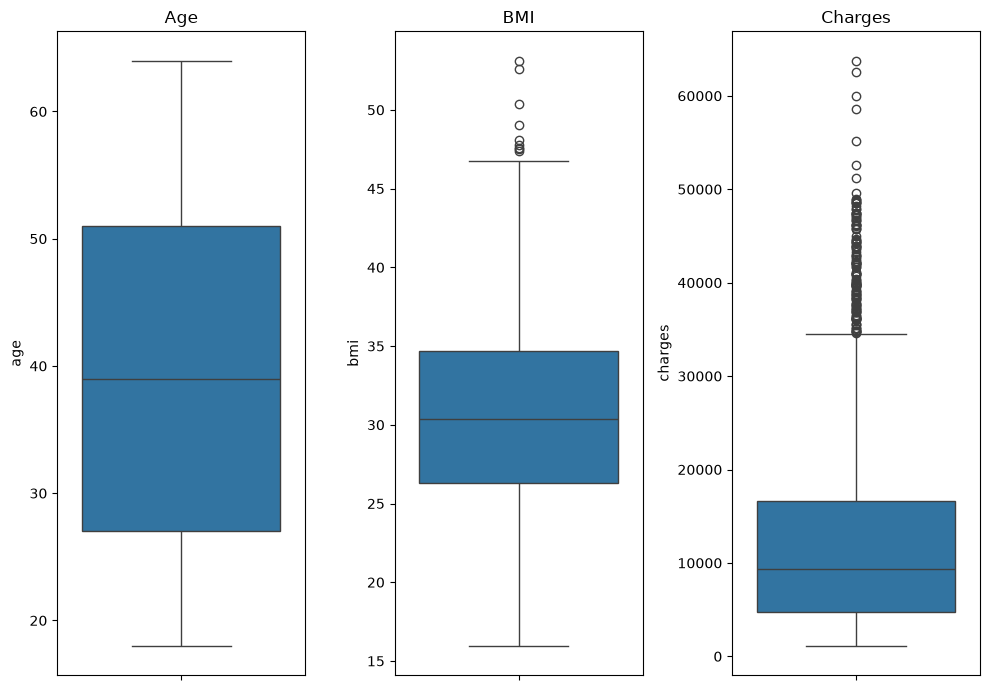

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(10,7))

sns.boxplot(y=df['age'], ax=axes[0])
axes[0].set_title('Age')

sns.boxplot(y=df['bmi'], ax=axes[1])
axes[1].set_title('BMI')

sns.boxplot(y=df['charges'], ax=axes[2])
axes[2].set_title('Charges')

plt.tight_layout()
plt.show()